In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.interpolate import griddata
from scipy.integrate import trapezoid
import os
import glob
import re

# --- Configuration ---
save_figures = False 
save_all_figures = False 
save_every = 10 
show_figures = False 

face_filename = 'faceNodesRightCPSFullCycleNoPower.csv'
name_tag = 'fullShotNewMesh5sSteady'
process_raw_data = False 

# --- Constants & Physics Functions ---
def P_vapor(T):
    """ Vapor pressure P [Pa] for Temperature T [K] """
    return 10**(12.4037 - 8283.1/T - 0.7081*np.log10(T))

def G_max(T):
    """ Max evaporation flux """
    R = 8.3145     # [J/mol-K]
    g = 10         # [m/s^2] (Effective gravity/acceleration)
    M = 6.941      # [g/mol] 
    
    # Conversion factor to [1/cm^2/s]
    uc = 0.1 * (6.022e23 / M) 
    return P_vapor(T) / (g * np.sqrt(2 * np.pi * R * T / M)) * uc

# Define the interpolation grid
x_min, x_max = 0.01, 0.06
y_min, y_max = -0.05, 0.05
num_points = 1000
grid_x, grid_y = np.mgrid[x_min:x_max:num_points*1j, y_min:y_max:num_points*1j]

# Area of a single grid cell in cm^2
dx_cm = ((x_max - x_min) / (num_points - 1)) * 100
dy_cm = ((y_max - y_min) / (num_points - 1)) * 100
dA_cm2 = dx_cm * dy_cm

# --- Data Loading ---
face_nodes_file = os.path.join("results", face_filename)
face_nodes_df = pd.read_csv(face_nodes_file, encoding="utf-8-sig")
target_node_ids = set(face_nodes_df['Node Number'])

file_pattern = os.path.join("results", f"{name_tag}_*s.csv")
data_files = glob.glob(file_pattern)

if process_raw_data:
    summary_temps = []
    times = []
    summary_evap_rates = []
    
    for i, file_path in enumerate(data_files):
        print(f"Processing {i+1}/{len(data_files)}")
        
        # Extract time using regex
        time_match = re.search(r"_(\d+\.?\d*)s", os.path.basename(file_path))
        if not time_match:
            continue
        time_val = float(time_match.group(1))
        
        # Load data (using latin1 for stability with engineering CSVs)
        df = pd.read_csv(file_path, encoding="latin1", sep='\t')
        nodes_subset = df[df['Node Number'].isin(target_node_ids)].copy()
        
        if nodes_subset.empty:
            print(f"Warning: No face nodes in {file_path}")
            continue

        points = nodes_subset[['X Location (m)', 'Y Location (m)']].values
        values = nodes_subset.iloc[:, 4].values # Assuming 5th column is Temp
        
        # Interpolate
        grid_z = griddata(points, values, (grid_x, grid_y), method='cubic')

        # Physics: Temp to Evap Rate (Convert atoms/cm2/s back to g/cm2/s)
        # Multiplication by M/N_A converts particle flux to mass flux
        evaporation_rate = G_max(grid_z + 273.15) * 6.941 / 6.022e23 

        total_evaporation_rate = np.nansum(evaporation_rate) * dA_cm2
        avg_temp = np.nanmean(grid_z)

        summary_temps.append(avg_temp)
        summary_evap_rates.append(total_evaporation_rate)
        times.append(time_val)

        # Plotting
        if save_figures or show_figures:
            # Temperature Plot
            fig, ax = plt.subplots(figsize=(9, 7))
            im = ax.imshow(grid_z.T, extent=(x_min, x_max, y_min, y_max), 
                           origin='lower', cmap='coolwarm', vmin=200, vmax=800)
            plt.colorbar(im, label='Temperature (°C)')
            ax.set_title(f"Surface Temp | Time: {time_val}s")
            
            if save_figures and (save_all_figures or i % save_every == 0):
                plt.savefig(f"plots/temp_{time_val}s_{name_tag}.png", dpi=300)
            if show_figures: plt.show()
            plt.close(fig) # Explicitly close to save memory

    # Sorting
    sort_idx = np.argsort(times)
    sorted_times = np.array(times)[sort_idx]
    sorted_evap = np.array(summary_evap_rates)[sort_idx]
    sorted_temps = np.array(summary_temps)[sort_idx]

    # Integration (Trapezoidal rule)
    total_evaporated = trapezoid(sorted_evap, x=sorted_times) * 2 
    
    # Export
    output_df = pd.DataFrame({
        'Time': sorted_times,
        'Average CPS Temperature': sorted_temps,
        'Total CPS Evaporation_Rate': sorted_evap,
        'Total Amount Evaporated': total_evaporated # Saved in every row for easy access
    })
    
    csv_name = f'output_data_{name_tag}_{face_filename}.csv'
    output_df.to_csv(csv_name, index=False)
    print(f"--- Processed data saved to {csv_name} ---")

else:
    processed_file = f'output_data_{name_tag}_{face_filename}.csv'
    df = pd.read_csv(processed_file)
    sorted_times = df['Time'].values
    sorted_temps = df['Average CPS Temperature'].values
    sorted_evap = df['Total CPS Evaporation_Rate'].values
    total_evaporated = df['Total Amount Evaporated'].iloc[0]
    print(f"Total Amount Evaporated: {total_evaporated:.4f} grams")

Total Amount Evaporated: 4.6397 grams


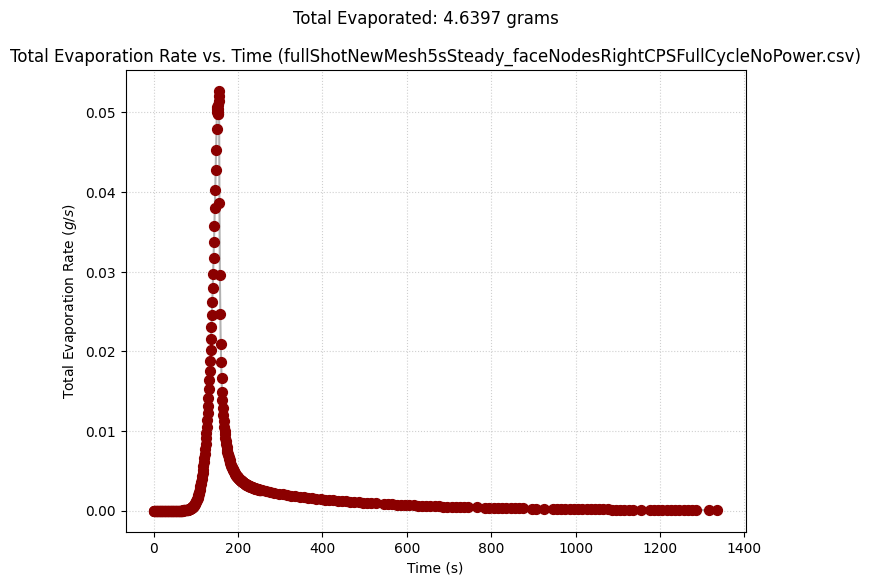

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(sorted_times, sorted_evap, color='darkred', s=50,  zorder=3)
plt.plot(sorted_times, sorted_evap, color='gray', alpha=0.6)
plt.title(f"Total Evaporation Rate vs. Time ({name_tag}_{face_filename})")
plt.suptitle(f"Total Evaporated: {total_evaporated:.4f} grams")
plt.xlabel("Time (s)")
plt.ylabel("Total Evaporation Rate ($g/s$)")
plt.grid(True, linestyle=':', alpha=0.6)
summary_save_name = f'evap_vs_time_summary_{name_tag}_{face_filename}.png'

if save_figures:
        plt.savefig(f"plots/{summary_save_name}", dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Summary plot saved as {summary_save_name}")



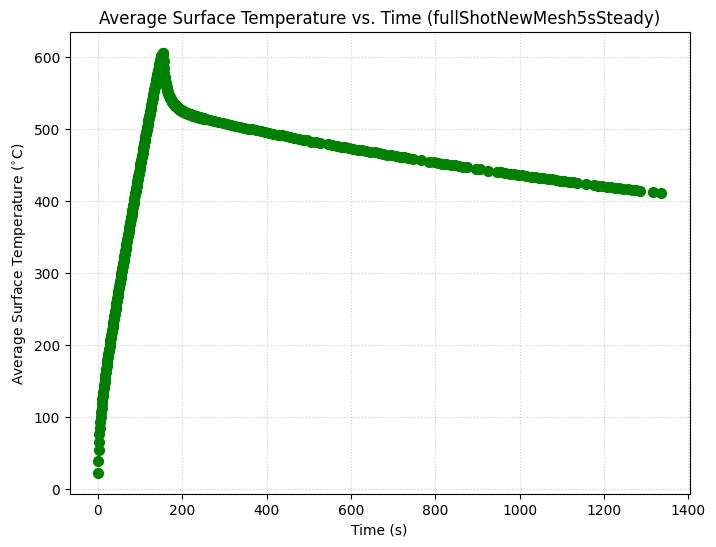

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(sorted_times, sorted_temps, color='green', s=50, zorder=3)


plt.title(f"Average Surface Temperature vs. Time ({name_tag})")
plt.xlabel("Time (s)")
plt.ylabel(r"Average Surface Temperature ($^{\circ}$C)")

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
if save_figures:
        summary_save_name = f'avgTemp_vs_time_{name_tag}.png'
        plt.savefig(f"plots/{summary_save_name}", dpi=300, bbox_inches='tight')
        print(f"Summary plot saved as {summary_save_name}")